<a href="https://colab.research.google.com/github/JustinRSK/2025_ML_EES/blob/main/Project/GrandeCaricaie_RF_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# GRANDE CARICAIE - RANDOM FOREST MODEL
# Simple master's thesis version
# ============================================================

!pip -q install rasterio scikit-learn joblib

import os
import glob
import json
import joblib
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

from rasterio.warp import reproject, Resampling

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

try:
    drive.mount("/content/drive", force_remount=True)
    MOUNT_POINT = "/content/drive"
except ValueError:
    drive.mount("/content/gdrive", force_remount=True)
    MOUNT_POINT = "/content/gdrive"

print("Drive mounted at:", MOUNT_POINT)

Mounted at /content/drive
Drive mounted at: /content/drive


In [3]:
# ============================================================
# 2. FILE PATHS
# ============================================================

FOLDER = os.path.join(MOUNT_POINT, "MyDrive", "GEE_Downloads")

feature_path = os.path.join(FOLDER, "GrandeCaricaie_RF_Features_2023.tif")

train_label_path = os.path.join(FOLDER, "labels_r1_train_except_Cheyres_ALIGNED.tif")
test_label_path  = os.path.join(FOLDER, "labels_r1_tst_Cheyres_ALIGNED.tif")

# If your test file is called "test" instead of "tst", this fixes it automatically
if not os.path.exists(test_label_path):
    test_label_path = os.path.join(FOLDER, "labels_r1_test_Cheyres_ALIGNED.tif")

output_folder = os.path.join(FOLDER, "RF_outputs")
os.makedirs(output_folder, exist_ok=True)

print("Feature raster:", feature_path)
print("Training labels:", train_label_path)
print("Test labels:", test_label_path)
print("Output folder:", output_folder)

Feature raster: /content/drive/MyDrive/GEE_Downloads/GrandeCaricaie_RF_Features_2023.tif
Training labels: /content/drive/MyDrive/GEE_Downloads/labels_r1_train_except_Cheyres_ALIGNED.tif
Test labels: /content/drive/MyDrive/GEE_Downloads/labels_r1_test_Cheyres_ALIGNED.tif
Output folder: /content/drive/MyDrive/GEE_Downloads/RF_outputs


In [4]:
# ============================================================
# 3. BASIC SETTINGS
# ============================================================

RANDOM_STATE = 42
MAX_PIXELS_PER_CLASS = 40000
BACKGROUND_VALUE = 0

class_names = {
    1: "Eaux libres",
    2: "Rivages et lieux humides",
    3: "Pelouses et prairies",
    4: "Milieux construits",
    5: "Plantations / champs / cultures",
    6: "Glaciers / rochers / éboulis / moraines",
    7: "Forêts",
    8: "Milieux indéterminés",
    9: "Autres"
}

def class_name(code):
    return class_names.get(int(code), f"Class {int(code)}")

In [5]:
# ============================================================
# 4. INSPECT FILES
# ============================================================

def raster_info(path, name):
    with rasterio.open(path) as src:
        print("\n" + name)
        print("-" * len(name))
        print("CRS:", src.crs)
        print("Size:", src.width, "x", src.height)
        print("Bands:", src.count)
        print("Resolution:", src.res)
        print("Nodata:", src.nodata)
        print("Data type:", src.dtypes[0])

raster_info(feature_path, "FEATURE RASTER")
raster_info(train_label_path, "TRAIN LABEL RASTER")
raster_info(test_label_path, "TEST LABEL RASTER")


FEATURE RASTER
--------------
CRS: EPSG:2056
Size: 3250 x 2493
Bands: 70
Resolution: (10.0, 10.0)
Nodata: None
Data type: float32

TRAIN LABEL RASTER
------------------
CRS: EPSG:2056
Size: 4251 x 3319
Bands: 1
Resolution: (7.653123100446938, 7.653123109370291)
Nodata: 0.0
Data type: uint8

TEST LABEL RASTER
-----------------
CRS: EPSG:2056
Size: 4251 x 3319
Bands: 1
Resolution: (7.653123100446938, 7.653123109370291)
Nodata: 0.0
Data type: uint8


In [6]:
# ============================================================
# 5. ALIGN LABELS TO FEATURE RASTER
# Important: labels must have same grid as Sentinel-2 features
# ============================================================

def align_label_to_features(label_path, feature_path, output_path):
    with rasterio.open(feature_path) as ref:
        ref_profile = ref.profile.copy()
        ref_crs = ref.crs
        ref_transform = ref.transform
        ref_height = ref.height
        ref_width = ref.width

    with rasterio.open(label_path) as src:
        label = src.read(1)

        aligned_label = np.zeros((ref_height, ref_width), dtype=np.uint8)

        reproject(
            source=label,
            destination=aligned_label,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            dst_nodata=0,
            resampling=Resampling.nearest
        )

    out_profile = ref_profile.copy()
    out_profile.update(
        count=1,
        dtype="uint8",
        nodata=0,
        compress="lzw"
    )

    with rasterio.open(output_path, "w", **out_profile) as dst:
        dst.write(aligned_label, 1)

    print("Saved:", output_path)

train_label_aligned = os.path.join(output_folder, "train_labels_aligned_to_features.tif")
test_label_aligned  = os.path.join(output_folder, "test_labels_aligned_to_features.tif")

align_label_to_features(train_label_path, feature_path, train_label_aligned)
align_label_to_features(test_label_path, feature_path, test_label_aligned)

train_label_path = train_label_aligned
test_label_path = test_label_aligned

Saved: /content/drive/MyDrive/GEE_Downloads/RF_outputs/train_labels_aligned_to_features.tif
Saved: /content/drive/MyDrive/GEE_Downloads/RF_outputs/test_labels_aligned_to_features.tif


In [7]:
# ============================================================
# 6. LOAD FEATURES AND LABELS
# ============================================================

with rasterio.open(feature_path) as src:
    features = src.read().astype("float32")
    profile = src.profile.copy()
    feature_nodata = src.nodata
    band_names = list(src.descriptions)

with rasterio.open(train_label_path) as src:
    train_labels = src.read(1)

with rasterio.open(test_label_path) as src:
    test_labels = src.read(1)

n_bands, n_rows, n_cols = features.shape

if band_names is None or all(b is None for b in band_names):
    band_names = [f"Band_{i+1}" for i in range(n_bands)]
else:
    band_names = [
        b if b is not None and b != "" else f"Band_{i+1}"
        for i, b in enumerate(band_names)
    ]

print("Feature shape:", features.shape)
print("Number of bands:", n_bands)
print("Train label shape:", train_labels.shape)
print("Test label shape:", test_labels.shape)


Feature shape: (70, 2493, 3250)
Number of bands: 70
Train label shape: (2493, 3250)
Test label shape: (2493, 3250)


In [8]:
# ============================================================
# 7. REMOVE BAD FEATURE BANDS
# This removes bands with NaN everywhere or constant values.
# It will remove band 70 if it is the problematic one.
# ============================================================

good_band_indices = []
removed_bands = []

for i in range(features.shape[0]):
    band = features[i]
    finite_values = np.isfinite(band)

    if finite_values.sum() == 0:
        removed_bands.append((i + 1, band_names[i], "all NaN"))
        continue

    band_min = np.nanmin(band)
    band_max = np.nanmax(band)

    if band_min == band_max:
        removed_bands.append((i + 1, band_names[i], "constant band"))
        continue

    good_band_indices.append(i)

print("Bands kept:", len(good_band_indices))
print("Bands removed:", len(removed_bands))

for b in removed_bands:
    print("Removed band:", b)

features = features[good_band_indices]
band_names = [band_names[i] for i in good_band_indices]

print("New feature shape:", features.shape)

Bands kept: 69
Bands removed: 1
Removed band: (70, 'slope', 'all NaN')
New feature shape: (69, 2493, 3250)


In [9]:
# ============================================================
# 8. CREATE VALID PIXEL MASK
# ============================================================

valid_features = np.all(np.isfinite(features), axis=0)

if feature_nodata is not None:
    valid_features &= np.all(features != feature_nodata, axis=0)

# Remove pixels where all remaining bands are zero
valid_features &= ~np.all(features == 0, axis=0)

print("Valid feature pixels:", valid_features.sum())
print("Total pixels:", valid_features.size)

Valid feature pixels: 110396
Total pixels: 8102250


In [10]:
# ============================================================
# 9. EXTRACT TRAINING AND TEST DATA
# ============================================================

def extract_samples(features, labels, valid_features, name):
    valid_labels = labels > BACKGROUND_VALUE
    valid_pixels = valid_features & valid_labels

    X = features[:, valid_pixels].T
    y = labels[valid_pixels].astype("int32")

    print("\n" + name)
    print("-" * len(name))
    print("Number of pixels:", len(y))
    print("Classes:", np.unique(y))

    counts = pd.Series(y).value_counts().sort_index()

    table = pd.DataFrame({
        "class_code": counts.index,
        "class_name": [class_name(c) for c in counts.index],
        "pixels": counts.values
    })

    display(table)

    return X, y

X_train_full, y_train_full = extract_samples(
    features,
    train_labels,
    valid_features,
    "TRAINING DATA"
)

X_test_full, y_test_full = extract_samples(
    features,
    test_labels,
    valid_features,
    "CHEYRES TEST DATA"
)


TRAINING DATA
-------------
Number of pixels: 76329
Classes: [1 2 3 4 7 8]


,class_code,class_name,pixels
0,1,Eaux libres,71949
1,2,Rivages et lieux humides,3877
2,3,Pelouses et prairies,8
3,4,Milieux construits,303
4,7,Forêts,179
5,8,Milieux indéterminés,13



CHEYRES TEST DATA
-----------------
Number of pixels: 7531
Classes: [1 2 3 4 7]


,class_code,class_name,pixels
0,1,Eaux libres,6763
1,2,Rivages et lieux humides,708
2,3,Pelouses et prairies,3
3,4,Milieux construits,6
4,7,Forêts,51


In [11]:
# ============================================================
# 10. LIMIT PIXELS PER CLASS
# Avoids RAM problems and reduces class imbalance
# ============================================================

def limit_pixels_per_class(X, y, max_pixels, random_state=42):
    rng = np.random.default_rng(random_state)
    selected_indices = []

    for cls in np.unique(y):
        indices = np.where(y == cls)[0]

        if len(indices) > max_pixels:
            indices = rng.choice(indices, size=max_pixels, replace=False)

        selected_indices.append(indices)

    selected_indices = np.concatenate(selected_indices)
    rng.shuffle(selected_indices)

    return X[selected_indices], y[selected_indices]

X_train, y_train = limit_pixels_per_class(
    X_train_full,
    y_train_full,
    MAX_PIXELS_PER_CLASS,
    RANDOM_STATE
)

X_test, y_test = limit_pixels_per_class(
    X_test_full,
    y_test_full,
    MAX_PIXELS_PER_CLASS,
    RANDOM_STATE
)

print("Final training data:", X_train.shape)
print("Final test data:", X_test.shape)

Final training data: (44380, 69)
Final test data: (7531, 69)


In [12]:
# ============================================================
# 11. INTERNAL VALIDATION SPLIT
# ============================================================

X_dev, X_val, y_dev, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Development data:", X_dev.shape)
print("Validation data:", X_val.shape)

Development data: (35504, 69)
Validation data: (8876, 69)


In [13]:
# ============================================================
# 12. TRAIN RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_dev, y_dev)

print("Random Forest trained.")
print("OOB score:", round(rf.oob_score_, 4))

Random Forest trained.
OOB score: 0.961


In [14]:
# ============================================================
# 13. EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, X, y, title, save_name):
    y_pred = model.predict(X)

    labels = np.unique(np.concatenate([y, y_pred]))
    names = [class_name(c) for c in labels]

    overall_accuracy = accuracy_score(y, y_pred)
    balanced_acc = balanced_accuracy_score(y, y_pred)
    macro_f1 = f1_score(y, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y, y_pred, average="weighted", zero_division=0)
    kappa = cohen_kappa_score(y, y_pred)

    print("\n" + title)
    print("=" * len(title))
    print("Overall accuracy:", round(overall_accuracy, 4))
    print("Balanced accuracy:", round(balanced_acc, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    print("Cohen's kappa:", round(kappa, 4))

    report = classification_report(
        y,
        y_pred,
        labels=labels,
        target_names=names,
        zero_division=0,
        output_dict=True
    )

    report_df = pd.DataFrame(report).T
    display(report_df)

    cm = confusion_matrix(y, y_pred, labels=labels)

    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    metrics = {
        "overall_accuracy": overall_accuracy,
        "balanced_accuracy": balanced_acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "cohen_kappa": kappa
    }

    report_df.to_csv(os.path.join(output_folder, f"{save_name}_classification_report.csv"))

    cm_df = pd.DataFrame(cm, index=names, columns=names)
    cm_df.to_csv(os.path.join(output_folder, f"{save_name}_confusion_matrix.csv"))

    with open(os.path.join(output_folder, f"{save_name}_metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    return metrics


Internal validation
Overall accuracy: 0.9605
Balanced accuracy: 0.5543
Macro F1: 0.6106
Weighted F1: 0.9597
Cohen's kappa: 0.7789


,precision,recall,f1-score,support
Eaux libres,0.979396,0.980375,0.979885,8000.000000
Rivages et lieux humides,0.787654,0.823226,0.805047,775.000000
Pelouses et prairies,0.000000,0.000000,0.000000,2.000000
Milieux construits,0.823529,0.466667,0.595745,60.000000
Forêts,0.636364,0.388889,0.482759,36.000000
Milieux indéterminés,1.000000,0.666667,0.800000,3.000000
accuracy,0.960455,0.960455,0.960455,0.960455
macro avg,0.704490,0.554304,0.610573,8876.000000
weighted avg,0.959995,0.960455,0.959725,8876.000000


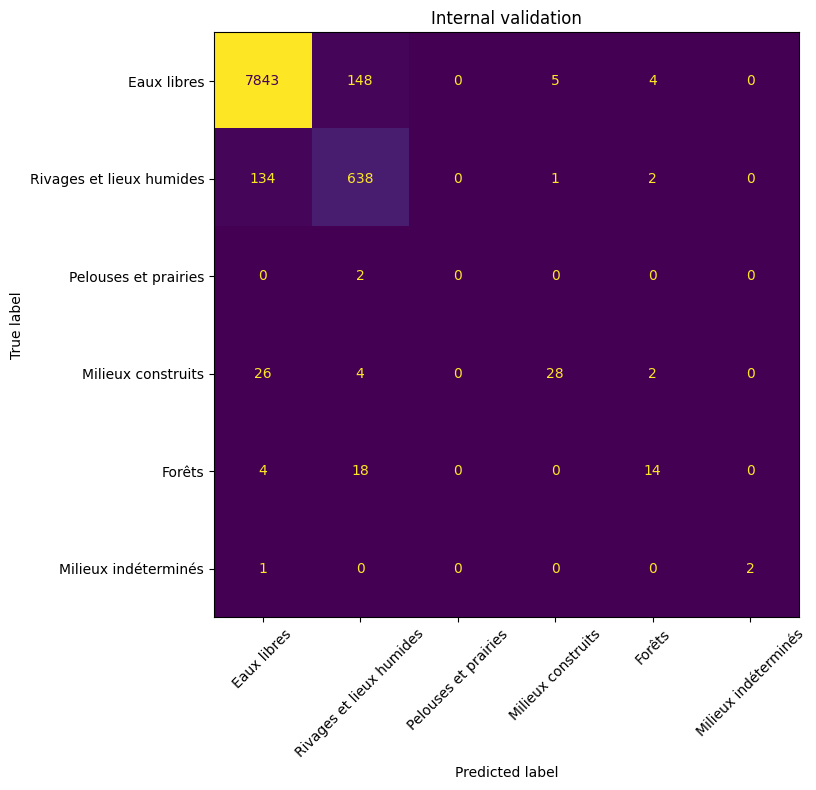

In [15]:
# ============================================================
# 14. INTERNAL VALIDATION
# ============================================================

validation_metrics = evaluate_model(
    rf,
    X_val,
    y_val,
    "Internal validation",
    "internal_validation"
)

In [16]:
# ============================================================
# 15. FINAL MODEL TRAINED ON ALL TRAINING DATA
# ============================================================

rf_final = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf_final.fit(X_train, y_train)

print("Final Random Forest trained.")
print("Final OOB score:", round(rf_final.oob_score_, 4))

Final Random Forest trained.
Final OOB score: 0.9622



Independent test on Cheyres
Overall accuracy: 0.9053
Balanced accuracy: 0.3931
Macro F1: 0.4286
Weighted F1: 0.9064
Cohen's kappa: 0.5027


,precision,recall,f1-score,support
Eaux libres,0.953325,0.945291,0.949291,6763.000000
Rivages et lieux humides,0.513784,0.579096,0.544489,708.000000
Pelouses et prairies,0.000000,0.000000,0.000000,3.000000
Milieux construits,1.000000,0.166667,0.285714,6.000000
Forêts,0.538462,0.274510,0.363636,51.000000
accuracy,0.905325,0.905325,0.905325,0.905325
macro avg,0.601114,0.393113,0.428626,7531.000000
weighted avg,0.908851,0.905325,0.906362,7531.000000


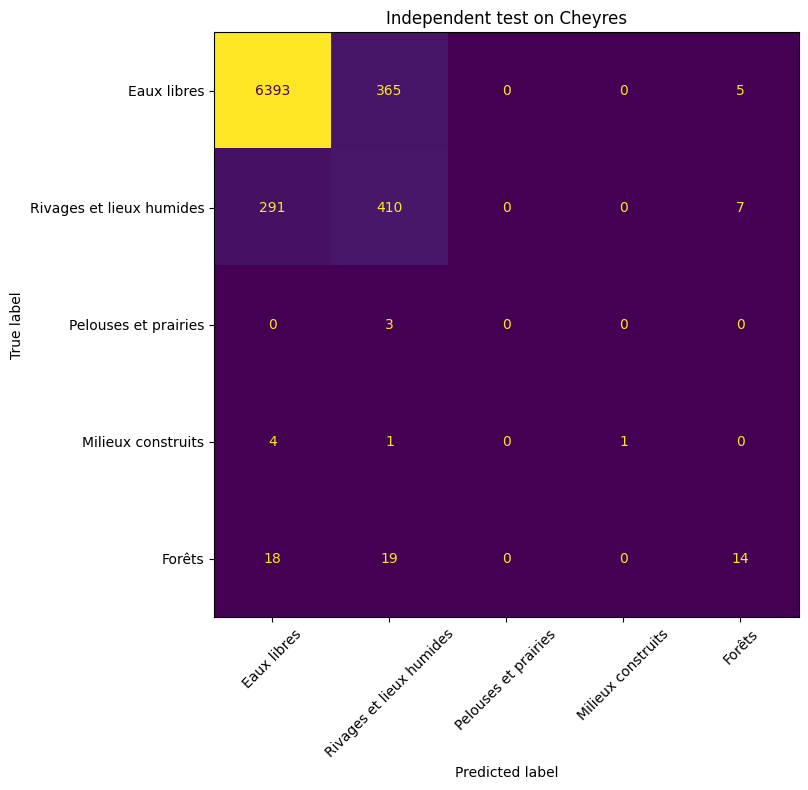

In [17]:
# ============================================================
# 16. INDEPENDENT TEST ON CHEYRES
# This is the most important evaluation for your thesis.
# ============================================================

cheyres_metrics = evaluate_model(
    rf_final,
    X_test,
    y_test,
    "Independent test on Cheyres",
    "cheyres_test"
)

,feature,importance
60,summer_S1_VV,0.039384
63,autumn_S1_VV,0.033699
28,summer_B12,0.030712
7,spring_B8A,0.029678
6,spring_B8,0.028767
...,...,...
56,autumn_BSI,0.006141
53,autumn_NBR,0.005666
32,summer_NDMI,0.004967
0,spring_B2,0.004784


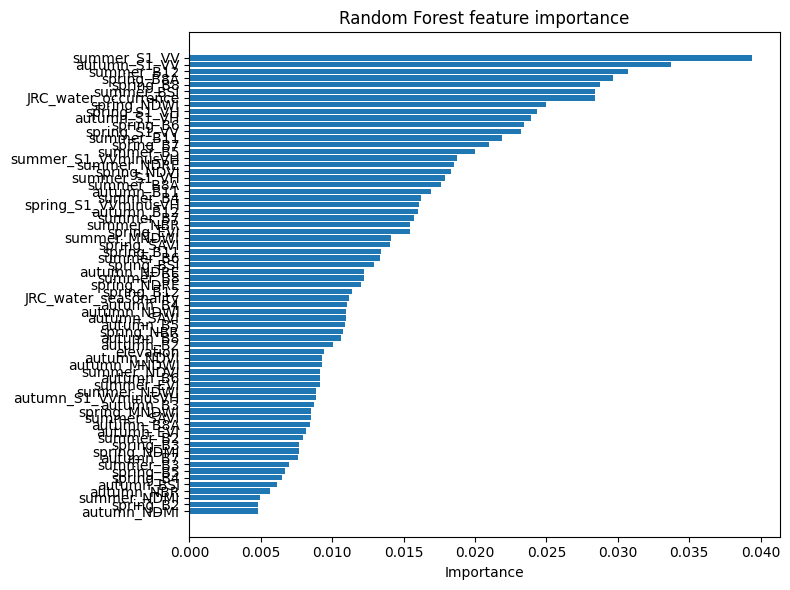

Saved: /content/drive/MyDrive/GEE_Downloads/RF_outputs/RF_feature_importance.csv


In [18]:
# ============================================================
# 17. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "feature": band_names,
    "importance": rf_final.feature_importances_
}).sort_values("importance", ascending=False)

display(importance)

importance_path = os.path.join(output_folder, "RF_feature_importance.csv")
importance.to_csv(importance_path, index=False)

plt.figure(figsize=(8, 6))
plt.barh(importance["feature"][::-1], importance["importance"][::-1])
plt.xlabel("Importance")
plt.title("Random Forest feature importance")
plt.tight_layout()
plt.show()

print("Saved:", importance_path)

In [19]:
# ============================================================
# 18. SAVE MODEL
# ============================================================

model_path = os.path.join(output_folder, "GrandeCaricaie_RF_model.joblib")
joblib.dump(rf_final, model_path)

print("Saved model:", model_path)

Saved model: /content/drive/MyDrive/GEE_Downloads/RF_outputs/GrandeCaricaie_RF_model.joblib


In [20]:
# ============================================================
# 19. PREDICT FULL MAP
# ============================================================

prediction_path = os.path.join(output_folder, "GrandeCaricaie_RF_prediction_2023.tif")
confidence_path = os.path.join(output_folder, "GrandeCaricaie_RF_confidence_2023.tif")

with rasterio.open(feature_path) as src:

    pred_profile = src.profile.copy()
    pred_profile.update(
        count=1,
        dtype="int16",
        nodata=0,
        compress="lzw"
    )

    conf_profile = src.profile.copy()
    conf_profile.update(
        count=1,
        dtype="float32",
        nodata=-9999,
        compress="lzw"
    )

    with rasterio.open(prediction_path, "w", **pred_profile) as dst_pred, \
         rasterio.open(confidence_path, "w", **conf_profile) as dst_conf:

        for _, window in src.block_windows(1):

            block = src.read(window=window).astype("float32")

            # Keep the same bands used during training
            block = block[good_band_indices]

            valid = np.all(np.isfinite(block), axis=0)
            valid &= ~np.all(block == 0, axis=0)

            h, w = valid.shape

            pred_block = np.zeros((h, w), dtype="int16")
            conf_block = np.full((h, w), -9999, dtype="float32")

            if valid.sum() > 0:
                X_block = block[:, valid].T

                pred = rf_final.predict(X_block)
                prob = rf_final.predict_proba(X_block)

                pred_block[valid] = pred.astype("int16")
                conf_block[valid] = prob.max(axis=1).astype("float32")

            dst_pred.write(pred_block, 1, window=window)
            dst_conf.write(conf_block, 1, window=window)

print("Saved prediction map:", prediction_path)
print("Saved confidence map:", confidence_path)

Saved prediction map: /content/drive/MyDrive/GEE_Downloads/RF_outputs/GrandeCaricaie_RF_prediction_2023.tif
Saved confidence map: /content/drive/MyDrive/GEE_Downloads/RF_outputs/GrandeCaricaie_RF_confidence_2023.tif


In [21]:
# ============================================================
# 20. AREA TABLE BY CLASS
# ============================================================

with rasterio.open(prediction_path) as src:
    prediction = src.read(1)
    transform = src.transform

pixel_area_m2 = abs(transform.a * transform.e)

values, counts = np.unique(prediction[prediction > 0], return_counts=True)

area_table = pd.DataFrame({
    "class_code": values.astype(int),
    "class_name": [class_name(v) for v in values],
    "pixels": counts,
    "area_m2": counts * pixel_area_m2,
    "area_ha": counts * pixel_area_m2 / 10000
})

area_table["area_percent"] = 100 * area_table["area_m2"] / area_table["area_m2"].sum()

display(area_table)

area_path = os.path.join(output_folder, "predicted_area_by_class.csv")
area_table.to_csv(area_path, index=False)

print("Saved area table:", area_path)

,class_code,class_name,pixels,area_m2,area_ha,area_percent
0,1,Eaux libres,103812,10381200.0,1038.12,94.036016
1,2,Rivages et lieux humides,5738,573800.0,57.38,5.197652
2,3,Pelouses et prairies,9,900.0,0.09,0.008152
3,4,Milieux construits,497,49700.0,4.97,0.450197
4,7,Forêts,309,30900.0,3.09,0.279901
5,8,Milieux indéterminés,31,3100.0,0.31,0.028081


Saved area table: /content/drive/MyDrive/GEE_Downloads/RF_outputs/predicted_area_by_class.csv


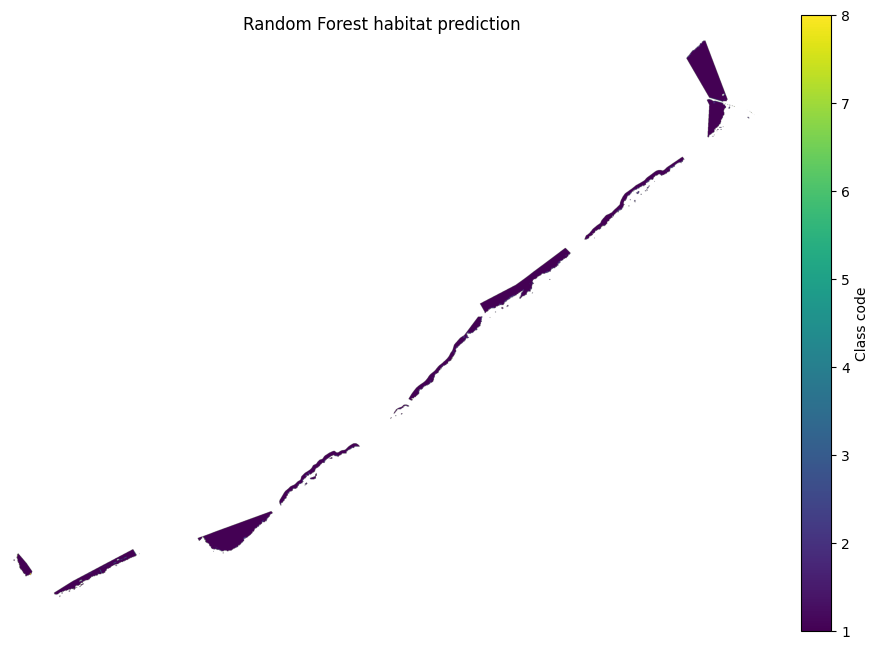

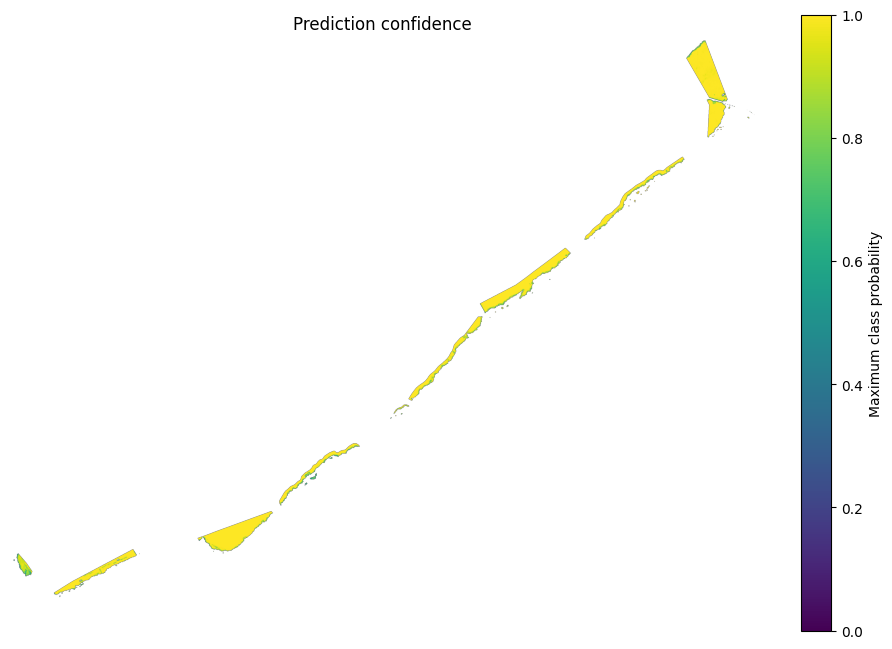

In [22]:
# ============================================================
# 21. QUICK MAP PREVIEW
# ============================================================

plt.figure(figsize=(12, 8))
plt.imshow(np.where(prediction == 0, np.nan, prediction))
plt.title("Random Forest habitat prediction")
plt.axis("off")
plt.colorbar(label="Class code")
plt.show()

with rasterio.open(confidence_path) as src:
    confidence = src.read(1)

plt.figure(figsize=(12, 8))
plt.imshow(np.where(confidence == -9999, np.nan, confidence), vmin=0, vmax=1)
plt.title("Prediction confidence")
plt.axis("off")
plt.colorbar(label="Maximum class probability")
plt.show()

In [23]:
# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print("DONE.")

print("\nMain files to import into QGIS:")
print("Prediction map:", prediction_path)
print("Confidence map:", confidence_path)

print("\nTables:")
print("Area table:", area_path)
print("Feature importance:", importance_path)

print("\nModel:")
print(model_path)

print("\nImportant thesis metrics from independent Cheyres test:")
for key, value in cheyres_metrics.items():
    print(key, ":", round(value, 4))

DONE.

Main files to import into QGIS:
Prediction map: /content/drive/MyDrive/GEE_Downloads/RF_outputs/GrandeCaricaie_RF_prediction_2023.tif
Confidence map: /content/drive/MyDrive/GEE_Downloads/RF_outputs/GrandeCaricaie_RF_confidence_2023.tif

Tables:
Area table: /content/drive/MyDrive/GEE_Downloads/RF_outputs/predicted_area_by_class.csv
Feature importance: /content/drive/MyDrive/GEE_Downloads/RF_outputs/RF_feature_importance.csv

Model:
/content/drive/MyDrive/GEE_Downloads/RF_outputs/GrandeCaricaie_RF_model.joblib

Important thesis metrics from independent Cheyres test:
overall_accuracy : 0.9053
balanced_accuracy : 0.3931
macro_f1 : 0.4286
weighted_f1 : 0.9064
cohen_kappa : 0.5027
